# Chapter 08. 작은 데이터 분석 프로젝트 완성하기

질문 정의 -> 원본 점검 -> 전처리 -> PK/FK 검증 -> 안전한 병합 -> completed 범위 확정 -> 집계 -> 총합 검증 -> 시각화 -> 익명화 -> Validation 저장 순서로 진행합니다.

## 1. 분석 질문 정의

| 분석 질문 | 주요 지표 | 결과 형태 |
|---|---|---|
| 카테고리별 completed 주문 기준 금액은 어떻게 다른가? | 수량, 금액, 금액 비중 | 집계표 + 막대그래프 |
| 월별 completed 주문 기준 금액/주문 수는 어떻게 변하는가? | 월별 금액, 주문 수, 평균 주문 금액 | 집계표 + 선그래프 |
| completed 주문 기준 구매 금액이 높은 고객은 누구인가? | 구매 금액, 주문 횟수, 평균 주문 금액 | 익명 집계표 + 막대그래프 |
| 주문 상태별 주문 수는 어떻게 분포하는가? | 상태별 주문 수, 비율 | 요약표 |

계산 기준: `line_total = quantity * unit_price`, 금액성 분석 대상은 `order_status == "completed"`.

In [66]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
for p in (project_root, *project_root.parents):
    if (p / "data").is_dir():
        project_root = p
        break

src_path = project_root / "src"
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocessing import (
    compare_shapes,
    duplicate_summary,
    missing_summary,
    preprocess_sales_data,
    validate_relationships,
)

reports_dir = project_root / "reports"
figures_dir = reports_dir / "figures"
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("project_root:", project_root)


project_root: c:\dev\python_basics


## 2. 원본 데이터 점검

In [67]:
raw_data = {
    "customers": pd.read_csv(project_root / "data" / "raw" / "customers.csv"),
    "products": pd.read_csv(project_root / "data" / "raw" / "products.csv"),
    "orders": pd.read_csv(project_root / "data" / "raw" / "orders.csv"),
    "order_items": pd.read_csv(project_root / "data" / "raw" / "order_items.csv"),
}

dataset_summary = pd.DataFrame(
    [
        {"dataset": name, "rows": df.shape[0], "columns": df.shape[1]}
        for name, df in raw_data.items()
    ]
)
dataset_summary.to_csv(reports_dir / "ch08_dataset_summary.csv", index=False)
dataset_summary


,dataset,rows,columns
0,customers,150,6
1,products,100,4
2,orders,300,5
3,order_items,764,5


## 3. 전처리 재실행과 Evidence 저장

In [68]:
processed_data = preprocess_sales_data(raw_data)

preprocessing_comparison = compare_shapes(raw_data, processed_data)
preprocessing_comparison.to_csv(
    reports_dir / "ch08_preprocessing_comparison.csv", index=False
)
preprocessing_comparison


,dataset,rows_raw,columns_raw,rows_processed,columns_processed
0,customers,150,6,150,6
1,order_items,764,5,764,6
2,orders,300,5,300,7
3,products,100,4,100,4


## 4. 주요 PK 결측/중복 검사

In [69]:
PK_COLUMNS = {
    "customers": "customer_id",
    "products": "product_id",
    "orders": "order_id",
    "order_items": "order_item_id",
}

pk_checks = pd.DataFrame(
    [
        {
            "dataset": name,
            "pk_column": pk,
            "missing_count": int(processed_data[name][pk].isna().sum()),
            "duplicate_count": int(processed_data[name][pk].duplicated().sum()),
        }
        for name, pk in PK_COLUMNS.items()
    ]
)
pk_checks.to_csv(reports_dir / "ch08_key_duplicate_checks.csv", index=False)
pk_checks


,dataset,pk_column,missing_count,duplicate_count
0,customers,customer_id,0,0
1,products,product_id,0,0
2,orders,order_id,0,0
3,order_items,order_item_id,0,0


## 5. FK 관계 검증

In [70]:
relationship_checks = validate_relationships(processed_data)
relationship_checks.to_csv(reports_dir / "ch08_relationship_checks.csv", index=False)
relationship_checks


,check,invalid_count
0,orders.customer_id exists in customers.custome...,0
1,order_items.order_id exists in orders.order_id,0
2,order_items.product_id exists in products.prod...,0


## 6. validate를 사용한 안전한 병합

In [71]:
orders_p = processed_data["orders"]
order_items_p = processed_data["order_items"]
products_p = processed_data["products"]
customers_p = processed_data["customers"]

before_rows = len(order_items_p)

order_sales = order_items_p.merge(
    orders_p[["order_id", "customer_id", "order_date", "order_status"]],
    on="order_id",
    how="left",
    validate="many_to_one",
    indicator=True,
)

after_rows = len(order_sales)
merge_indicator_counts = order_sales["_merge"].value_counts()

merge_checks = pd.DataFrame(
    [
        {
            "check": "order_items -> orders (many_to_one)",
            "rows_before": before_rows,
            "rows_after": after_rows,
            "left_only": int(merge_indicator_counts.get("left_only", 0)),
            "right_only": int(merge_indicator_counts.get("right_only", 0)),
            "both": int(merge_indicator_counts.get("both", 0)),
        }
    ]
)
merge_checks.to_csv(reports_dir / "ch08_merge_checks.csv", index=False)
merge_checks


,check,rows_before,rows_after,left_only,right_only,both
0,order_items -> orders (many_to_one),764,764,0,0,764


## 7. line_total 재검증

In [72]:
expected_line_total = order_sales["quantity"] * order_sales["unit_price"]
line_total_mismatch = int((order_sales["line_total"] != expected_line_total).sum())
print("line_total mismatch count:", line_total_mismatch)


line_total mismatch count: 0


## 8. completed 주문 범위 확정과 카테고리 연결

In [73]:
completed_order_sales = order_sales.loc[
    order_sales["order_status"].eq("completed")
].copy()

completed_sales_items = completed_order_sales.merge(
    products_p[["product_id", "category"]],
    on="product_id",
    how="left",
    validate="many_to_one",
)

completed_total = completed_order_sales["line_total"].sum()
print("completed_total:", completed_total)
print("category 결측 행 수:", int(completed_sales_items["category"].isna().sum()))


completed_total: 148990000
category 결측 행 수: 0


## 9. 카테고리 / 월 / 고객 집계

In [74]:
category_sales = (
    completed_sales_items
    .groupby("category", as_index=False, dropna=False)
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("line_total", "sum"),
    )
    .sort_values("total_sales", ascending=False)
    .reset_index(drop=True)
)
category_sales["sales_ratio_pct"] = (
    category_sales["total_sales"] / category_sales["total_sales"].sum() * 100
).round(2)
category_sales


,category,total_quantity,total_sales,sales_ratio_pct
0,스포츠,295,31743000,21.31
1,전자기기,259,26400000,17.72
2,생활용품,272,23915000,16.05
3,뷰티,223,23383000,15.69
4,식품,133,16573000,11.12
5,도서,149,16389000,11.00
6,패션,111,10587000,7.11


In [75]:
invalid_date_count = int(
    completed_order_sales["order_date"].isna().sum()
)
monthly_source = completed_order_sales.dropna(subset=["order_date"]).copy()
monthly_source["order_month"] = (
    monthly_source["order_date"].dt.to_period("M").astype(str)
)

monthly_sales = (
    monthly_source
    .groupby("order_month", as_index=False)
    .agg(
        total_sales=("line_total", "sum"),
        order_count=("order_id", "nunique"),
    )
    .sort_values("order_month")
    .reset_index(drop=True)
)
monthly_sales["avg_order_value"] = (
    monthly_sales["total_sales"] / monthly_sales["order_count"]
).round(2)

print("completed 주문 중 order_date 결측 행 수:", invalid_date_count)
monthly_sales


completed 주문 중 order_date 결측 행 수: 0


,order_month,total_sales,order_count,avg_order_value
0,2025-07,5869000,8,733625.00
1,2025-08,15621000,18,867833.33
2,2025-09,10190000,13,783846.15
3,2025-10,25766000,26,991000.00
4,2025-11,8812000,12,734333.33
5,2025-12,11501000,14,821500.00
6,2026-01,17423000,22,791954.55
7,2026-02,9749000,17,573470.59
8,2026-03,13429000,14,959214.29
9,2026-04,17553000,23,763173.91


In [76]:
customer_sales_internal = (
    completed_order_sales
    .groupby("customer_id", as_index=False)
    .agg(
        order_count=("order_id", "nunique"),
        total_sales=("line_total", "sum"),
    )
    .sort_values("total_sales", ascending=False)
    .reset_index(drop=True)
)
customer_sales_internal["avg_order_value"] = (
    customer_sales_internal["total_sales"] / customer_sales_internal["order_count"]
).round(2)

customer_sales_internal = customer_sales_internal.merge(
    customers_p[["customer_id", "city"]], on="customer_id", how="left"
)

# 공개용 익명 라벨 (원본 customer_id는 공개 결과에서 제거)
customer_sales = customer_sales_internal.copy()
customer_sales["customer_label"] = [
    f"Customer {i:02d}" for i in range(1, len(customer_sales) + 1)
]
customer_sales = customer_sales[
    ["customer_label", "city", "order_count", "total_sales", "avg_order_value"]
]
customer_sales.head(10)


,customer_label,city,order_count,total_sales,avg_order_value
0,Customer 01,성남,5,4100000,820000.0
1,Customer 02,고양,4,3996000,999000.0
2,Customer 03,수원,4,3880000,970000.0
3,Customer 04,서울,5,3590000,718000.0
4,Customer 05,서울,4,3523000,880750.0
5,Customer 06,인천,2,3191000,1595500.0
6,Customer 07,성남,2,3178000,1589000.0
7,Customer 08,광주,3,3153000,1051000.0
8,Customer 09,서울,4,3093000,773250.0
9,Customer 10,부산,2,2990000,1495000.0


In [77]:
key_map = {
    "customers": "customer_id",
    "products": "product_id",
    "orders": "order_id",
    "order_items": "order_item_id",
}

In [78]:
missing_count = int(frame[key].isna().sum())
print(missing_count)

0


In [79]:
kp_checks = []

for dataset, key in key_map.items():
    frame = processed_data[dataset]
    missing_count = int(frame[key].isna().sum())
    duplicated_count = int(frame[key].duplicated().sum())
    if missing_count == 0 and duplicated_count == 0:
        status = "PASS"
    else:
        status = "FAIL"
    kp_checks.append(
        {
            "dataset": dataset,
            "key": key,
            "missing_count": missing_count,
            "duplicated_count": duplicated_count,
            "status": status,
        }
    )

In [80]:
kp_checks

[{'dataset': 'customers',
  'key': 'customer_id',
  'missing_count': 0,
  'duplicated_count': 0,
  'status': 'PASS'},
 {'dataset': 'products',
  'key': 'product_id',
  'missing_count': 0,
  'duplicated_count': 0,
  'status': 'PASS'},
 {'dataset': 'orders',
  'key': 'order_id',
  'missing_count': 0,
  'duplicated_count': 0,
  'status': 'PASS'},
 {'dataset': 'order_items',
  'key': 'order_item_id',
  'missing_count': 0,
  'duplicated_count': 0,
  'status': 'PASS'}]

In [81]:
duplicated_count = frame[key].duplicated()
print(duplicated_count)

0      False
1      False
2      False
3      False
4      False
       ...  
759    False
760    False
761    False
762    False
763    False
Name: order_item_id, Length: 764, dtype: bool


In [82]:
orders = processed_data["orders"]
order_items = processed_data["order_items"]

In [83]:
orders = raw_data["orders"]
order_items = raw_data["order_items"]

In [85]:
order_sales = order_items.merge(
    orders[
        [
            "order_id",
            "customer_id",
            "order_date",
            "order_status",
        ]
    ],

    on="order_id",
    how="left",
    validate="many_to_one",
    indicator=True,

)


In [ ]:
print(len(order_items))
print(len(order_sales))
order_sales["_merge"].value_counts(dropna=False)

764
764


_merge
both          764
left_only       0
right_only      0
Name: count, dtype: int64

In [ ]:
expected_line_total = order_items["quantity"] * order_items["unit_price"]
expected_line_total

0      306000
1      125000
2      426000
3      579000
4      756000
        ...  
759    112000
760    696000
761    378000
762    700000
763    160000
Length: 764, dtype: int64

In [ ]:
if "line_total" in order_items.columns:
    order_items["line_total"] = expected_line_total

order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 764 entries, 0 to 763
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   order_item_id  764 non-null    int64
 1   order_id       764 non-null    int64
 2   product_id     764 non-null    int64
 3   quantity       764 non-null    int64
 4   unit_price     764 non-null    int64
dtypes: int64(5)
memory usage: 30.0 KB


In [ ]:
completed_order_sales = order_sales.loc[
    order_sales["order_status"].eq("completed")
]

completed_order_sales.head()

,order_item_id,order_id,product_id,quantity,unit_price,customer_id,order_date,order_status,_merge
0,1,1,100,3,102000,123,2026-05-07,completed,both
1,2,1,87,5,25000,123,2026-05-07,completed,both
2,3,1,7,3,142000,123,2026-05-07,completed,both
3,4,1,9,3,193000,123,2026-05-07,completed,both
12,13,6,83,3,24000,87,2026-03-21,completed,both


In [ ]:
print("전체 주문 건수 :" ,len(order_sales))
print("전체 주문 건수(completed) :" ,len(completed_order_sales) )
print("전체 주문 건수(compeleted 외) :", len(order_sales) - len(completed_order_sales) )





전체 주문 건수 : 764
전체 주문 건수(completed) : 474
전체 주문 건수(compeleted 외) : 290


In [88]:
order_status_sales = (
    completed_order_sales
    .groupby("order_status",as_index=False)
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales = ("line_total", "sum")
    )
    .sort_values("total_sales", ascending=False)
)

## 10. 총합 일치(total consistency) 검증

In [ ]:
category_total = category_sales["total_sales"].sum()
monthly_total = monthly_sales["total_sales"].sum()
customer_total = customer_sales["total_sales"].sum()

TOLERANCE = 1e-6

total_consistency_check = pd.DataFrame(
    [
        {"comparison": "completed_total vs category_total",
         "match": bool(abs(completed_total - category_total) < TOLERANCE)},
        {"comparison": "completed_total vs monthly_total",
         "match": bool(abs(completed_total - monthly_total) < TOLERANCE)},
        {"comparison": "completed_total vs customer_total",
         "match": bool(abs(completed_total - customer_total) < TOLERANCE)},
    ]
)
total_consistency_check.to_csv(
    reports_dir / "ch08_total_consistency_check.csv", index=False
)
total_consistency_check


,comparison,match
0,completed_total vs category_total,True
1,completed_total vs monthly_total,True
2,completed_total vs customer_total,True


월별 합계는 `order_date` 결측 행을 제외하고 계산하므로, 결측이 있으면 `completed_total`과 `monthly_total`이 달라질 수 있습니다. 위 표의 두 번째 행이 `False`라면 `invalid_date_count`를 먼저 확인해야 합니다.

## 11. 주문 상태별 분포 (전체 orders 범위)

In [ ]:
order_status_summary = (
    orders_p["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="order_count")
)
order_status_summary["ratio_pct"] = (
    order_status_summary["order_count"] / order_status_summary["order_count"].sum() * 100
).round(2)
order_status_summary.to_csv(
    reports_dir / "ch08_order_status_summary.csv", index=False
)
order_status_summary


,order_status,order_count,ratio_pct
0,completed,184,61.33
1,cancelled,64,21.33
2,refunded,52,17.33


## 12. 검증된 집계표로 시각화

C:\Users\sweet\AppData\Local\Temp\ipykernel_37652\4018191186.py:7: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\sweet\AppData\Local\Temp\ipykernel_37652\4018191186.py:7: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\sweet\AppData\Local\Temp\ipykernel_37652\4018191186.py:7: UserWarning: Glyph 52768 (\N{HANGUL SYLLABLE CEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\sweet\AppData\Local\Temp\ipykernel_37652\4018191186.py:7: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\sweet\AppData\Local\Temp\ipykernel_37652\4018191186.py:7: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\sweet\AppData\Local\Temp\ipykernel_37652\4018191186.py:7: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s

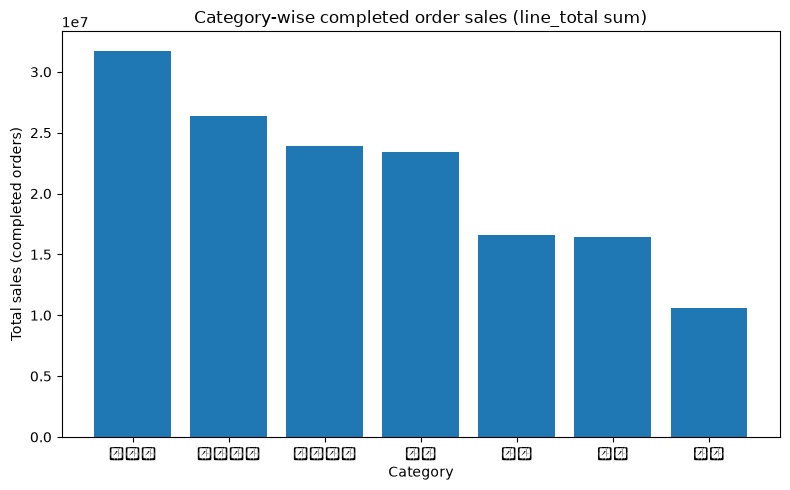

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(category_sales["category"].astype(str), category_sales["total_sales"])
ax.set_title("Category-wise completed order sales (line_total sum)")
ax.set_xlabel("Category")
ax.set_ylabel("Total sales (completed orders)")
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(figures_dir / "ch08_category_sales.png", dpi=150)
plt.show()


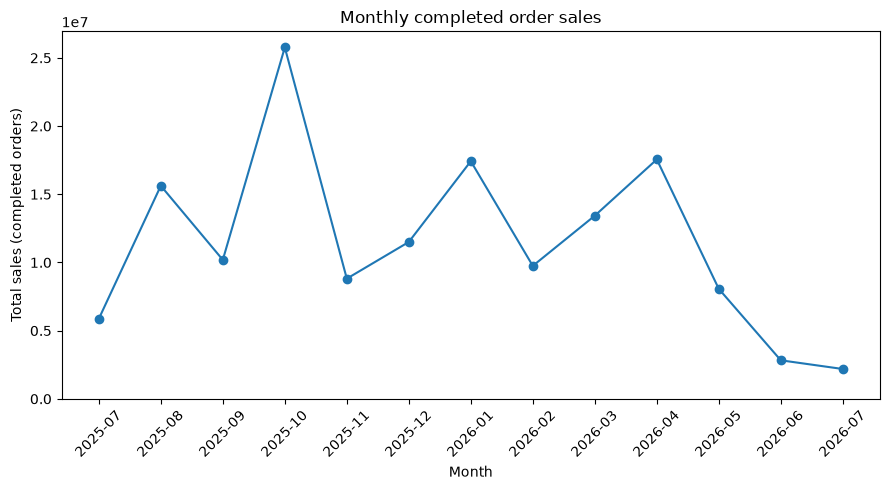

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly_sales["order_month"], monthly_sales["total_sales"], marker="o")
ax.set_title("Monthly completed order sales")
ax.set_xlabel("Month")
ax.set_ylabel("Total sales (completed orders)")
ax.set_ylim(bottom=0)
plt.xticks(rotation=45)
fig.tight_layout()
fig.savefig(figures_dir / "ch08_monthly_sales.png", dpi=150)
plt.show()


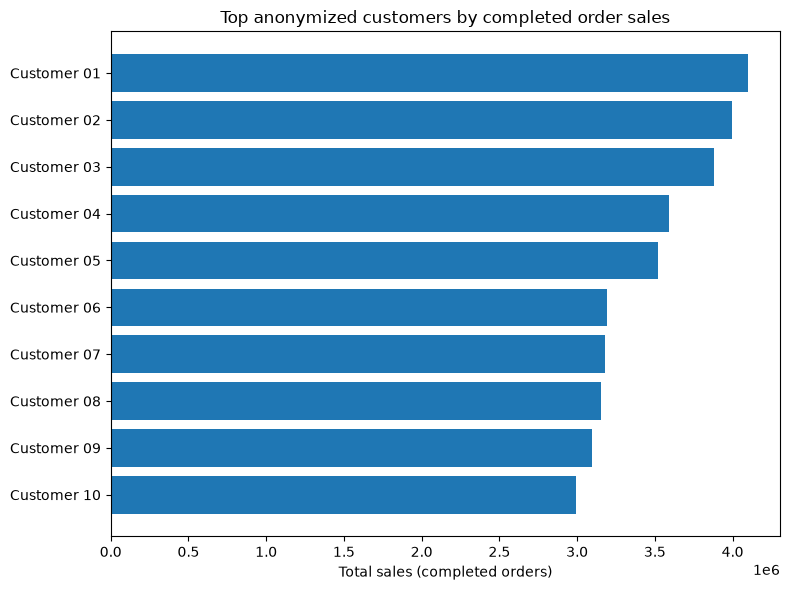

In [ ]:
top_customers = customer_sales.head(10).sort_values("total_sales")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_customers["customer_label"], top_customers["total_sales"])
ax.set_title("Top anonymized customers by completed order sales")
ax.set_xlabel("Total sales (completed orders)")
ax.set_xlim(left=0)
fig.tight_layout()
fig.savefig(figures_dir / "ch08_top_customers.png", dpi=150)
plt.show()


## 13. 공개 산출물 저장과 개인정보 재검사

In [ ]:
category_sales.to_csv(reports_dir / "ch08_category_sales.csv", index=False)
monthly_sales.to_csv(reports_dir / "ch08_monthly_sales.csv", index=False)
customer_sales.to_csv(reports_dir / "ch08_customer_sales.csv", index=False)

# 저장한 CSV를 다시 읽어 민감 컬럼이 없는지 재검사
reloaded_customer_sales = pd.read_csv(reports_dir / "ch08_customer_sales.csv")
sensitive_columns = {"name", "email", "phone", "address", "customer_id"}
leaked_columns = sensitive_columns.intersection(reloaded_customer_sales.columns)
print("공개 고객 결과에 남은 민감 컬럼:", leaked_columns or "없음")


공개 고객 결과에 남은 민감 컬럼: 없음


## 14. 자동 검증 결과(PASS/FAIL) 저장

In [ ]:
validation_checks = [
    {
        "check": "pk_no_missing_or_duplicate",
        "result": bool(
            (pk_checks["missing_count"] == 0).all()
            and (pk_checks["duplicate_count"] == 0).all()
        ),
    },
    {
        "check": "fk_no_invalid_references",
        "result": bool((relationship_checks["invalid_count"] == 0).all()),
    },
    {
        "check": "merge_checks_pass",
        "result": bool(
            (merge_checks["left_only"] == 0).all()
            and (merge_checks["rows_before"] == merge_checks["rows_after"]).all()
        ),
    },
    {
        "check": "line_total_matches_quantity_times_unit_price",
        "result": line_total_mismatch == 0,
    },
    {
        "check": "completed_total_consistency",
        "result": bool(total_consistency_check["match"].all()),
    },
    {
        "check": "completed_rows_with_invalid_order_date",
        "result": invalid_date_count == 0,
    },
    {
        "check": "customer_sales_no_sensitive_columns",
        "result": len(leaked_columns) == 0,
    },
]

project_validation = pd.DataFrame(validation_checks)
project_validation["status"] = project_validation["result"].map(
    {True: "PASS", False: "FAIL"}
)
project_validation.to_csv(
    reports_dir / "ch08_project_validation.csv", index=False
)

overall_status = "PASS" if project_validation["result"].all() else "FAIL"
print("전체 프로젝트 검증 결과:", overall_status)
project_validation


전체 프로젝트 검증 결과: PASS


,check,result,status
0,pk_no_missing_or_duplicate,True,PASS
1,fk_no_invalid_references,True,PASS
2,merge_checks_pass,True,PASS
3,line_total_matches_quantity_times_unit_price,True,PASS
4,completed_total_consistency,True,PASS
5,completed_rows_with_invalid_order_date,True,PASS
6,customer_sales_no_sensitive_columns,True,PASS


## 15. 관찰과 가설 구분

- **관찰**: `category_sales`에서 가장 높은 `total_sales`를 가진 카테고리를 확인한다 (데이터에서 직접 확인된 사실).
- **가설**: 그 카테고리의 매출이 높은 이유(마케팅, 계절성 등)는 현재 데이터만으로는 검증할 수 없다.
- **추가 검증**: 원인을 확인하려면 광고/마케팅 집행 데이터, 채널별 유입 데이터 등이 추가로 필요하다.

`total_sales`, `sales_ratio_pct`는 completed 주문에 포함된 `line_total`의 합계이며, 할인/배송비/세금/부분환불/수수료를 반영한 회계상 순매출이 아니다.